# 074: KmerSeek HP — Family AUC Mechanism Analysis

Addresses three priority reviewer questions:

1. **Is the lift real?** FoldSeek FAM AUC on KmerSeek's covered queries (head-to-head).
2. **Selection bias?** Covered vs uncovered query characterisation (SCOPe class, family peer count).
3. **Where does FoldSeek lose?** Class breakdown of queries where KmerSeek finds family hits that FoldSeek misses.

Uses `exclude_gray_zone=True` (paper convention), k=29 (best FAM k from notebook 068 Bonferroni sweep).

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, gc
from pathlib import Path
from collections import Counter

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu

sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import (
    EVAL_USECOLS, BENCH_DIR, TEA_DIR, SCOPE_CLASS_DESCRIPTIONS,
    load_eval, load_baselines, add_composite_scores_scope,
    recompute_bonferroni, eval_tsv_to_rocx, sensitivity_stats,
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120

K_FAM           = 29          # best FAM k from notebook 068 excl_gz Bonferroni sweep
EXCLUDE_GZ      = True
BONF_THRESHOLD  = 0.05
SCORE_COL       = 'jaccard'
FIG_PREFIX      = '../figures/074'

## 2. Load data

In [3]:
foldseek, tea_all = load_baselines(TEA_DIR)
ref_queries = set(foldseek['NAME'].to_list())
print(f'FoldSeek queries: {len(foldseek):,}')

# Load KmerSeek k=29 — keep subseq cols for identity analysis
ALL_COLS = EVAL_USECOLS + ['q_scop_family', 'q_scop_class', 'query_subseq', 'target_subseq',
              'query_start', 'query_end', 'region_length']
ev_full = load_eval(K_FAM, columns=ALL_COLS)
ev = ev_full.drop(['query_subseq', 'target_subseq', 'q_scop_family', 'q_scop_class',
                   'query_start', 'query_end', 'region_length'])
ev = add_composite_scores_scope(ev)
ev = recompute_bonferroni(ev)
ev_filt = ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
print(f'k={K_FAM} after Bonf<{BONF_THRESHOLD}: {len(ev_filt):,} pairs')

# Restore seq cols on filtered rows for identity analysis (section 8)
ev_filt_seq = ev_filt.join(
    ev_full.select(['query_domain', 'target_domain', 'query_subseq', 'target_subseq',
                   'query_start', 'query_end', 'region_length']),
    on=['query_domain', 'target_domain'], how='left')

km_rocx   = eval_tsv_to_rocx(ev_filt, score_col=SCORE_COL, ascending=False,
                               exclude_gray_zone=EXCLUDE_GZ)
km_rocx_r = km_rocx.filter(pl.col('NAME').is_in(ref_queries))
covered   = set(km_rocx_r['NAME'].to_list())
uncovered = ref_queries - covered

n_km_total = km_rocx['NAME'].n_unique()
print(f'KmerSeek total covered (all):      {n_km_total:,}  (queries with ≥1 Bonf-sig hit)')
print(f'KmerSeek covered in benchmark:     {len(covered):,}  ({100*len(covered)/len(ref_queries):.1f}% of FoldSeek ref)')
print(f'KmerSeek-only (outside benchmark): {n_km_total - len(covered):,}')
print(f'KmerSeek uncovered (ref):          {len(uncovered):,}')
del ev, ev_filt; gc.collect()

FoldSeek queries: 5,713
k=29 after Bonf<0.05: 785 pairs
KmerSeek total covered (all):      164  (queries with ≥1 Bonf-sig hit)
KmerSeek covered in benchmark:     60  (1.1% of FoldSeek ref)
KmerSeek-only (outside benchmark): 104
KmerSeek uncovered (ref):          5,653


20

## 3. Priority 1: Head-to-head — FoldSeek FAM AUC on KmerSeek's covered queries

The honest comparison: both methods evaluated on the **same** set of queries.

In [4]:
fs_cov  = foldseek.filter(pl.col('NAME').is_in(covered))
tea_cov = tea_all.filter(pl.col('NAME').is_in(covered))

# KmerSeek on its OWN full covered set (164 queries, no FoldSeek benchmark restriction)
_, _, km_fam_own  = sensitivity_stats(km_rocx,   'FAM')
_, _, km_sfam_own = sensitivity_stats(km_rocx,   'SFAM')

# KmerSeek restricted to ref_queries intersection (60 queries), for head-to-head
_, _, km_fam   = sensitivity_stats(km_rocx_r, 'FAM')
_, _, km_sfam  = sensitivity_stats(km_rocx_r, 'SFAM')

# Baselines
_, _, fs_fam   = sensitivity_stats(foldseek,  'FAM')
_, _, fs_sfam  = sensitivity_stats(foldseek,  'SFAM')
_, _, fsc_fam  = sensitivity_stats(fs_cov,    'FAM')
_, _, fsc_sfam = sensitivity_stats(fs_cov,    'SFAM')
_, _, teac_fam = sensitivity_stats(tea_cov,   'FAM')

print('=== KmerSeek standalone (own covered queries) ===')
print(f'{"Method":<50} {"FAM AUC":>9} {"SFAM AUC":>10}  n_queries')
print('-' * 80)
print(f'{"KmerSeek k=29 Bonf<0.05 excl_gz (ALL covered)":<50} {km_fam_own:>9.4f} {km_sfam_own:>10.4f}  {n_km_total:,}')

print()
print('=== Head-to-head: benchmark intersection only (60 shared queries) ===')
print(f'{"Method":<50} {"FAM AUC":>9} {"SFAM AUC":>10}  n_queries')
print('-' * 80)
print(f'{"FoldSeek (all queries)":<50} {fs_fam:>9.4f} {fs_sfam:>10.4f}  {foldseek["NAME"].n_unique():,}')
print(f'{"FoldSeek (KmerSeek-covered queries)":<50} {fsc_fam:>9.4f} {fsc_sfam:>10.4f}  {len(covered):,}')
print(f'{"TEA (KmerSeek-covered queries)":<50} {teac_fam:>9.4f}  {"n/a":>10}  {len(covered):,}')
print(f'{"KmerSeek k=29 Bonf<0.05 excl_gz (matched)":<50} {km_fam:>9.4f} {km_sfam:>10.4f}  {len(covered):,}')

=== KmerSeek standalone (own covered queries) ===
Method                                               FAM AUC   SFAM AUC  n_queries
--------------------------------------------------------------------------------
KmerSeek k=29 Bonf<0.05 excl_gz (ALL covered)         0.9909     0.0701  164

=== Head-to-head: benchmark intersection only (60 shared queries) ===
Method                                               FAM AUC   SFAM AUC  n_queries
--------------------------------------------------------------------------------
FoldSeek (all queries)                                0.8169     0.5743  5,713
FoldSeek (KmerSeek-covered queries)                   0.8819     0.6983  60
TEA (KmerSeek-covered queries)                        0.9388         n/a  60
KmerSeek k=29 Bonf<0.05 excl_gz (matched)             0.9833     0.0583  60


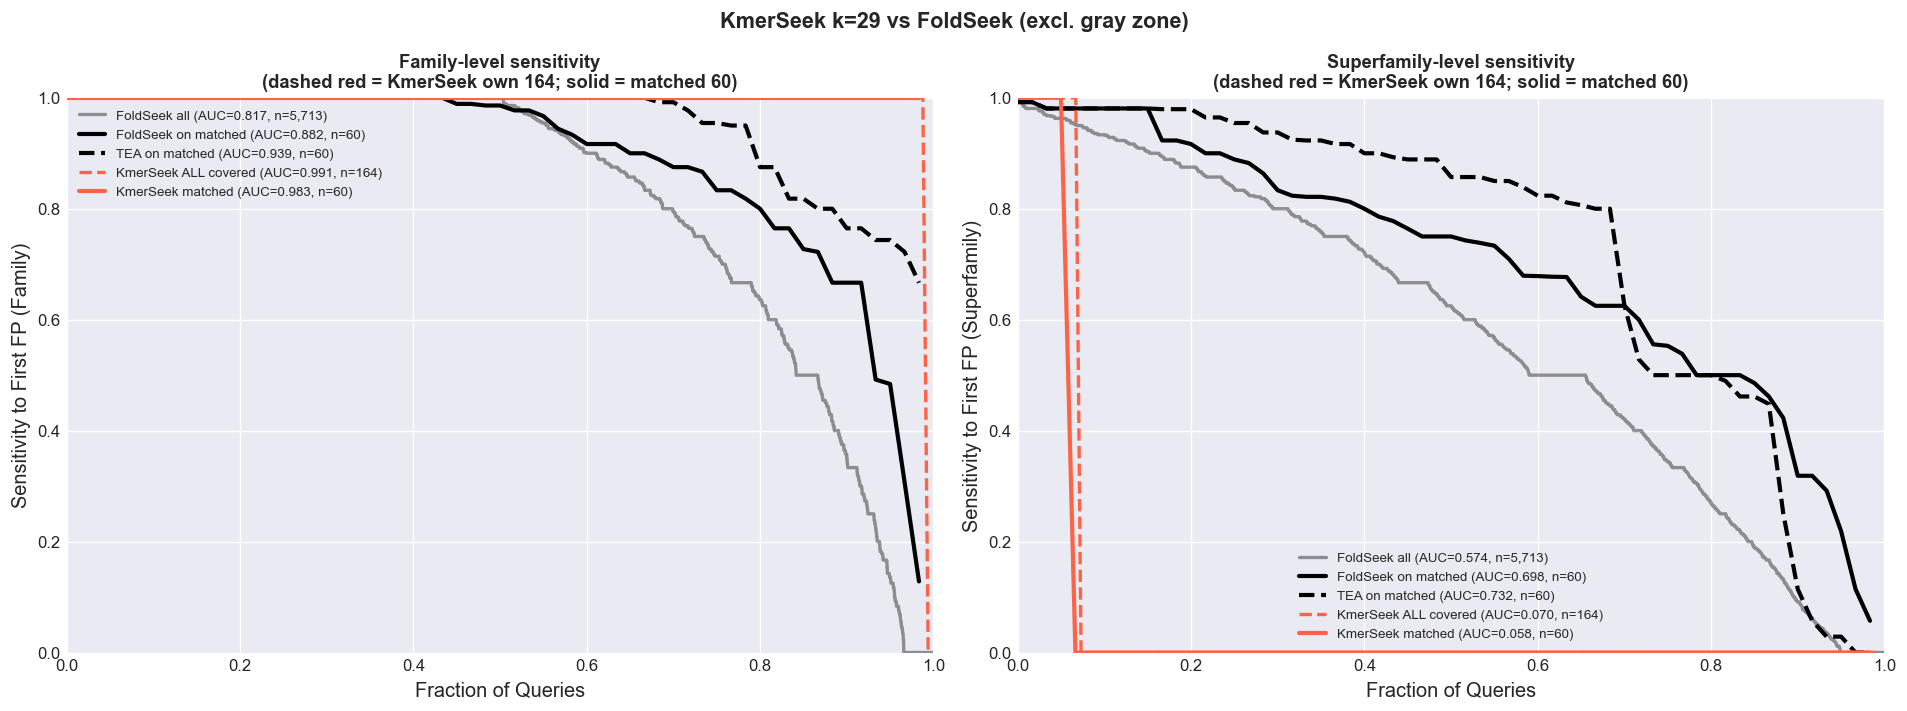

In [5]:
# Sensitivity curves: KmerSeek own (164) + head-to-head (60 intersection)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (lc, ll) in zip(axes, [('FAM', 'Family'), ('SFAM', 'Superfamily')]):
    frac, sens, auc = sensitivity_stats(foldseek, lc)
    ax.plot(frac, sens, 'k-', lw=2, alpha=0.4, label=f'FoldSeek all (AUC={auc:.3f}, n={foldseek["NAME"].n_unique():,})')
    frac, sens, auc = sensitivity_stats(fs_cov, lc)
    ax.plot(frac, sens, 'k-', lw=2.5, label=f'FoldSeek on matched (AUC={auc:.3f}, n={len(covered):,})')
    frac, sens, auc = sensitivity_stats(tea_cov, lc)
    ax.plot(frac, sens, 'k--', lw=2.5, label=f'TEA on matched (AUC={auc:.3f}, n={len(covered):,})')
    # KmerSeek on its own full set (164)
    frac, sens, auc = sensitivity_stats(km_rocx, lc)
    ax.plot(frac, sens, color='tomato', lw=2, ls='--',
            label=f'KmerSeek ALL covered (AUC={auc:.3f}, n={n_km_total:,})')
    # KmerSeek on matched set (60)
    frac, sens, auc = sensitivity_stats(km_rocx_r, lc)
    ax.plot(frac, sens, color='tomato', lw=2.5,
            label=f'KmerSeek matched (AUC={auc:.3f}, n={len(covered):,})')
    ax.set_xlabel('Fraction of Queries', fontsize=12)
    ax.set_ylabel(f'Sensitivity to First FP ({ll})', fontsize=12)
    ax.set_title(f'{ll}-level sensitivity\n(dashed red = KmerSeek own 164; solid = matched 60)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.suptitle(f'KmerSeek k={K_FAM} vs FoldSeek (excl. gray zone)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_head_to_head_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

Per-query family sensitivity comparison (on KmerSeek-covered queries)
  KmerSeek FAM > FoldSeek FAM:  33 queries
  FoldSeek FAM > KmerSeek FAM:  0 queries
  Both detect (FAM>0):          60
  KmerSeek only (FAM>0):        0
  FoldSeek only (FAM>0):        0
  Neither detects:              0


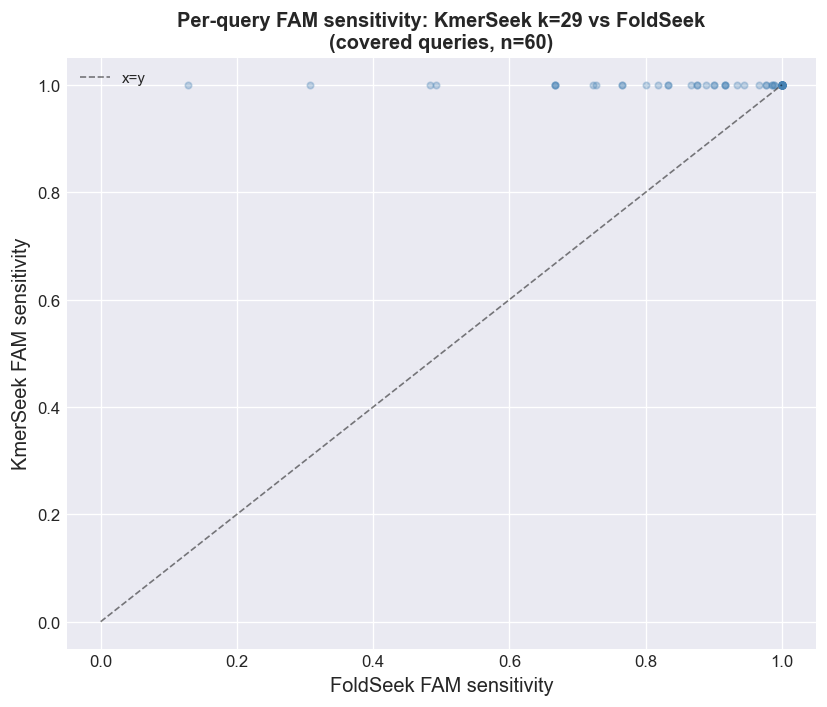

In [6]:
# Per-query sensitivity: KmerSeek vs FoldSeek on covered set
km_per_q  = km_rocx_r.select(['NAME', 'FAM']).rename({'FAM': 'km_fam'})
fs_per_q  = fs_cov.select(['NAME', 'FAM']).rename({'FAM': 'fs_fam'})
per_q = km_per_q.join(fs_per_q, on='NAME', how='left')

km_beats_fs  = per_q.filter(pl.col('km_fam') > pl.col('fs_fam'))
fs_beats_km  = per_q.filter(pl.col('fs_fam') > pl.col('km_fam'))
both_detect  = per_q.filter((pl.col('km_fam') > 0) & (pl.col('fs_fam') > 0))
km_only      = per_q.filter((pl.col('km_fam') > 0) & (pl.col('fs_fam') == 0))
fs_only      = per_q.filter((pl.col('km_fam') == 0) & (pl.col('fs_fam') > 0))
neither      = per_q.filter((pl.col('km_fam') == 0) & (pl.col('fs_fam') == 0))

print('Per-query family sensitivity comparison (on KmerSeek-covered queries)')
print(f'  KmerSeek FAM > FoldSeek FAM:  {len(km_beats_fs):,} queries')
print(f'  FoldSeek FAM > KmerSeek FAM:  {len(fs_beats_km):,} queries')
print(f'  Both detect (FAM>0):          {len(both_detect):,}')
print(f'  KmerSeek only (FAM>0):        {len(km_only):,}')
print(f'  FoldSeek only (FAM>0):        {len(fs_only):,}')
print(f'  Neither detects:              {len(neither):,}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(per_q['fs_fam'].to_numpy(), per_q['km_fam'].to_numpy(),
           alpha=0.3, s=15, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='x=y')
ax.set_xlabel('FoldSeek FAM sensitivity', fontsize=12)
ax.set_ylabel('KmerSeek FAM sensitivity', fontsize=12)
ax.set_title(f'Per-query FAM sensitivity: KmerSeek k={K_FAM} vs FoldSeek\n(covered queries, n={len(covered):,})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_per_query_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Priority 2: Selection bias — covered vs uncovered query characterisation

Is the covered set biased toward easy queries (large families, specific SCOPe classes)?

In [7]:
# SCOPe class from FoldSeek ROCX (one class per query)
def scop_class_of(query_set: set, rocx: pl.DataFrame) -> pl.DataFrame:
    return (rocx.filter(pl.col('NAME').is_in(query_set))
                .select(['NAME', 'SCOP'])
                .unique()
                .with_columns(pl.col('SCOP').str.slice(0, 1).alias('cls')))

cls_covered   = scop_class_of(covered,   foldseek)
cls_uncovered = scop_class_of(uncovered, foldseek)

# Family peer count: how many other ref_queries share the same 4-part SCOP family?
scop_df = (foldseek.select(['NAME', 'SCOP']).unique()
           .with_columns(
               pl.col('SCOP').str.split('.').list.slice(0, 4).list.join('.').alias('fam4')
           ))
fam_sizes = (scop_df.group_by('fam4')
                    .agg(pl.len().alias('fam_peer_count'))
                    .with_columns((pl.col('fam_peer_count') - 1).alias('fam_peers')))
scop_with_peers = scop_df.join(fam_sizes, on='fam4', how='left')

peers_covered   = scop_with_peers.filter(pl.col('NAME').is_in(covered))['fam_peers'].to_numpy()
peers_uncovered = scop_with_peers.filter(pl.col('NAME').is_in(uncovered))['fam_peers'].to_numpy()

stat, pval = mannwhitneyu(peers_covered, peers_uncovered, alternative='greater')
print('Family peer count: covered vs uncovered queries')
print(f'  Covered:   mean={peers_covered.mean():.2f}  median={np.median(peers_covered):.0f}')
print(f'  Uncovered: mean={peers_uncovered.mean():.2f}  median={np.median(peers_uncovered):.0f}')
print(f'  Mann-Whitney U (covered > uncovered): p={pval:.4f}')

Family peer count: covered vs uncovered queries
  Covered:   mean=32.27  median=16
  Uncovered: mean=21.54  median=9
  Mann-Whitney U (covered > uncovered): p=0.0004


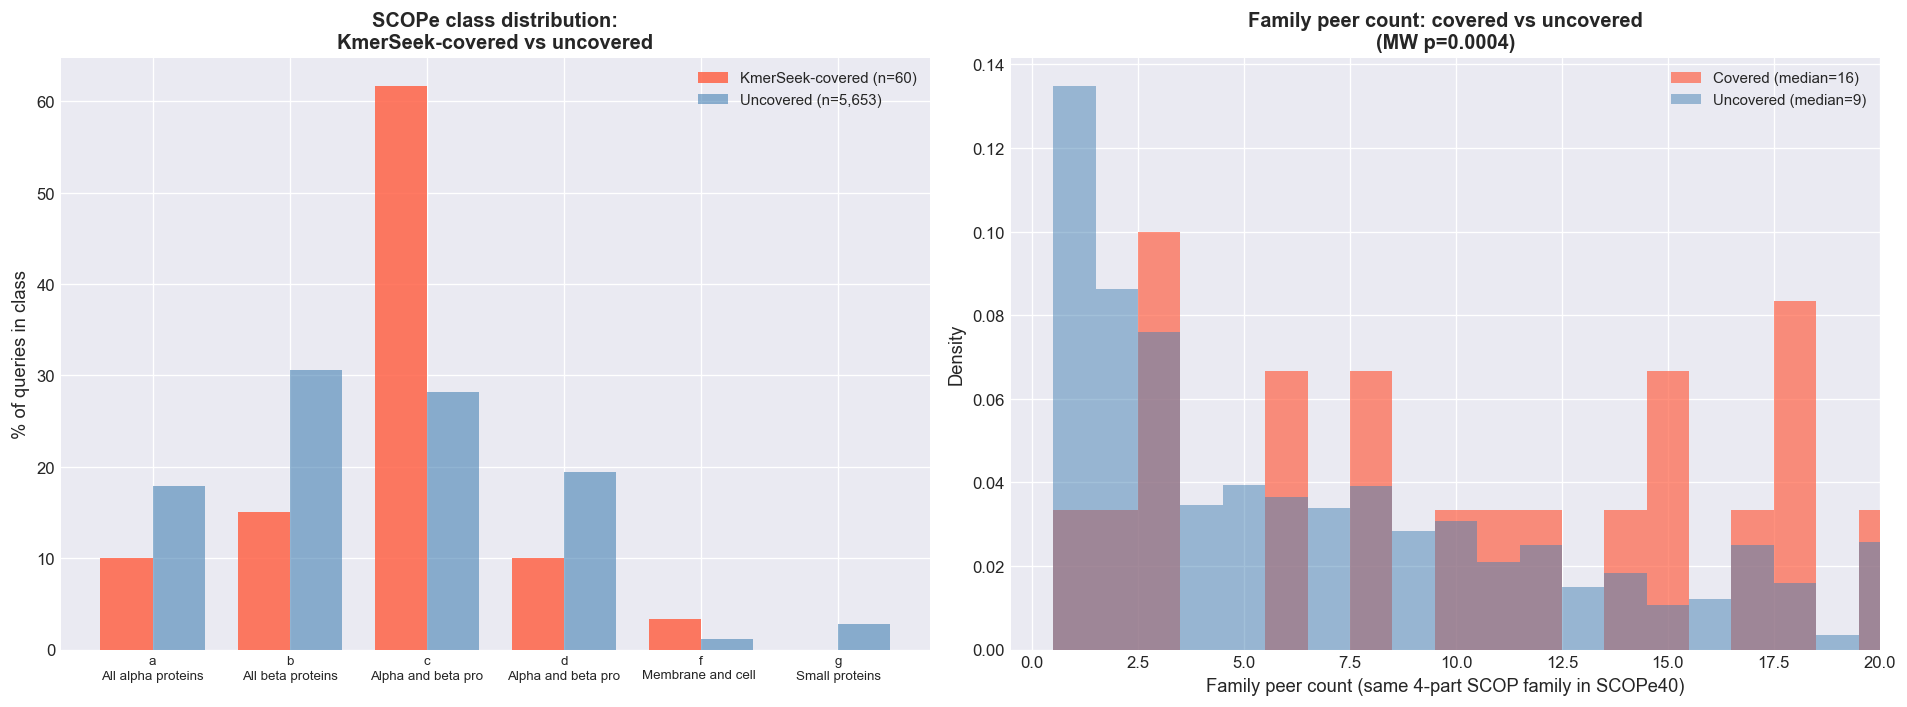

In [8]:
# Plot: SCOPe class composition + family peer distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Class distribution
ax = axes[0]
all_cls = sorted(set(cls_covered['cls'].to_list()) | set(cls_uncovered['cls'].to_list()))
n_cov = len(covered); n_unc = len(uncovered)
pct_cov = Counter(cls_covered['cls'].to_list())
pct_unc = Counter(cls_uncovered['cls'].to_list())
x = np.arange(len(all_cls)); w = 0.38
ax.bar(x - w/2, [pct_cov.get(c, 0) / n_cov * 100 for c in all_cls], w,
       color='tomato', alpha=0.85, label=f'KmerSeek-covered (n={n_cov:,})')
ax.bar(x + w/2, [pct_unc.get(c, 0) / n_unc * 100 for c in all_cls], w,
       color='steelblue', alpha=0.6, label=f'Uncovered (n={n_unc:,})')
ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n{SCOPE_CLASS_DESCRIPTIONS.get(c,c)[:18]}' for c in all_cls], fontsize=8)
ax.set_ylabel('% of queries in class', fontsize=11)
ax.set_title('SCOPe class distribution:\nKmerSeek-covered vs uncovered', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Family peer count distribution
ax = axes[1]
bins = np.arange(0, max(peers_covered.max(), peers_uncovered.max()) + 2) - 0.5
ax.hist(peers_covered,   bins=bins, density=True, alpha=0.7, color='tomato',
        label=f'Covered (median={np.median(peers_covered):.0f})')
ax.hist(peers_uncovered, bins=bins, density=True, alpha=0.5, color='steelblue',
        label=f'Uncovered (median={np.median(peers_uncovered):.0f})')
ax.set_xlabel('Family peer count (same 4-part SCOP family in SCOPe40)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Family peer count: covered vs uncovered\n(MW p={pval:.4f})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim(-0.5, 20)
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_covered_vs_uncovered.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Priority 3: Where does FoldSeek lose at family level?

On KmerSeek's covered queries, FoldSeek detects all of them at FAM level too — so
"KM-only detections" is zero by construction. The right question is where KmerSeek
achieves **higher sensitivity**: queries where `km_fam > fs_fam` are ones where HP
k-mers rank true family members better than 3Di.

In [9]:
# Where does KmerSeek beat FoldSeek per query?
km_beats_names = set(km_beats_fs['NAME'].to_list())
fs_beats_names = set(fs_beats_km['NAME'].to_list())
tied_names     = set(per_q.filter(pl.col('km_fam') == pl.col('fs_fam'))['NAME'].to_list())

cls_km_beats = scop_class_of(km_beats_names, foldseek)
cls_fs_beats = scop_class_of(fs_beats_names, foldseek)
cls_tied     = scop_class_of(tied_names,     foldseek)

cnt_km_b = Counter(cls_km_beats['cls'].to_list())
cnt_fs_b = Counter(cls_fs_beats['cls'].to_list())
cnt_tied = Counter(cls_tied['cls'].to_list())
all_c    = sorted(set(cnt_km_b) | set(cnt_fs_b) | set(cnt_tied))

print(f'KmerSeek FAM > FoldSeek FAM: {len(km_beats_names):,} queries')
print(f'FoldSeek FAM > KmerSeek FAM: {len(fs_beats_names):,} queries')
print(f'Tied:                         {len(tied_names):,} queries')
print()
print(f'  {"Class":<5} {"KM>FS":>8} {"FS>KM":>8} {"Tied":>8}  Description')
print(f'  {"-"*65}')
for c in all_c:
    print(f'  {c:<5} {cnt_km_b.get(c,0):>8} {cnt_fs_b.get(c,0):>8} {cnt_tied.get(c,0):>8}  '
          f'{SCOPE_CLASS_DESCRIPTIONS.get(c,c)[:40]}')

KmerSeek FAM > FoldSeek FAM: 33 queries
FoldSeek FAM > KmerSeek FAM: 0 queries
Tied:                         27 queries

  Class    KM>FS    FS>KM     Tied  Description
  -----------------------------------------------------------------
  a            5        0        1  All alpha proteins
  b            6        0        3  All beta proteins
  c           18        0       19  Alpha and beta proteins (a/b) — alternat
  d            4        0        2  Alpha and beta proteins (a+b) — segregat
  f            0        0        2  Membrane and cell surface proteins


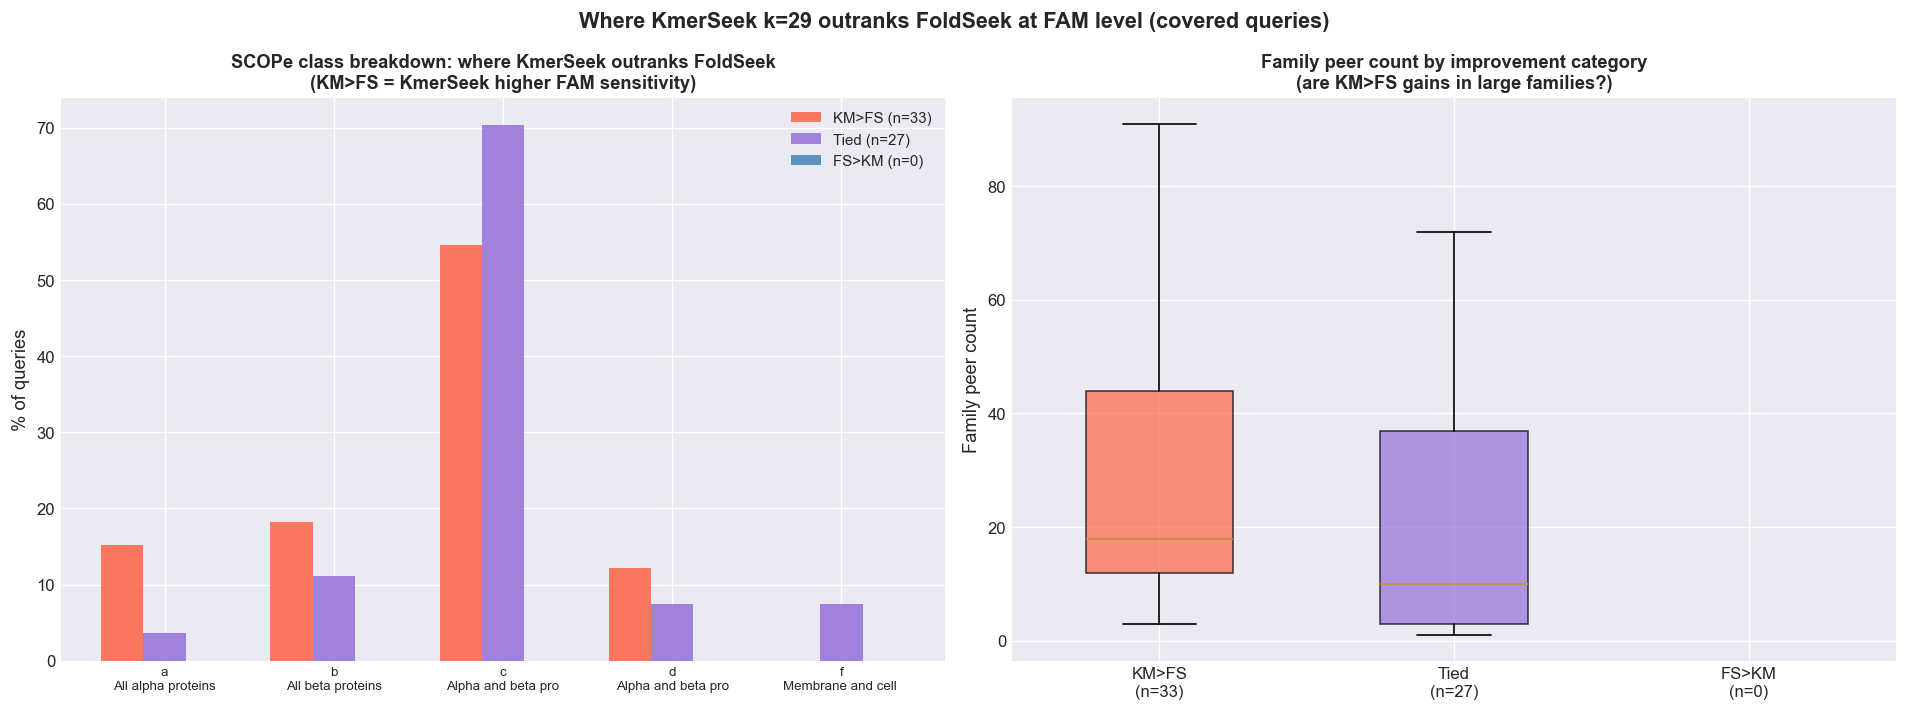

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: class breakdown of KM>FS vs FS>KM vs tied
ax = axes[0]
groups = [('KM>FS', cnt_km_b, 'tomato'), ('Tied', cnt_tied, 'mediumpurple'), ('FS>KM', cnt_fs_b, 'steelblue')]
x = np.arange(len(all_c)); w = 0.25
for i, (label, cnt, color) in enumerate(groups):
    n = sum(cnt.values())
    ax.bar(x + (i - 1) * w, [cnt.get(c, 0) / max(n, 1) * 100 for c in all_c],
           w, color=color, alpha=0.85, label=f'{label} (n={n})')
ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n{SCOPE_CLASS_DESCRIPTIONS.get(c,c)[:18]}' for c in all_c], fontsize=8)
ax.set_ylabel('% of queries', fontsize=11)
ax.set_title('SCOPe class breakdown: where KmerSeek outranks FoldSeek\n(KM>FS = KmerSeek higher FAM sensitivity)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Right: family peer count by improvement category
ax = axes[1]
def peers_of(qset):
    return scop_with_peers.filter(pl.col('NAME').is_in(qset))['fam_peers'].to_numpy()

data_groups = [
    ('KM>FS', peers_of(km_beats_names), 'tomato'),
    ('Tied',  peers_of(tied_names),     'mediumpurple'),
    ('FS>KM', peers_of(fs_beats_names), 'steelblue'),
]
bp = ax.boxplot([d for _, d, _ in data_groups], positions=list(range(len(data_groups))),
                patch_artist=True, widths=0.5, showfliers=False)
for patch, (_, _, color) in zip(bp['boxes'], data_groups):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(list(range(len(data_groups))))
ax.set_xticklabels([f'{lbl}\n(n={len(d)})' for lbl, d, _ in data_groups], fontsize=10)
ax.set_ylabel('Family peer count', fontsize=11)
ax.set_title('Family peer count by improvement category\n(are KM>FS gains in large families?)',
             fontsize=11, fontweight='bold')

plt.suptitle(f'Where KmerSeek k={K_FAM} outranks FoldSeek at FAM level (covered queries)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_km_beats_fs_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. AUC lift across k-sizes (head-to-head)

Shows whether the lift is consistent across k or concentrated at one point.

In [11]:
KSIZES = list(range(15, 46))

rows = []
for k in KSIZES:
    try:
        _ev = load_eval(k, columns=EVAL_USECOLS)
        _ev = add_composite_scores_scope(_ev)
        _ev = recompute_bonferroni(_ev)
        _ev = _ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
        _rocx = eval_tsv_to_rocx(_ev, score_col=SCORE_COL, ascending=False,
                                  exclude_gray_zone=EXCLUDE_GZ)
        _rocx_r = _rocx.filter(pl.col('NAME').is_in(ref_queries))
        _cov = set(_rocx_r['NAME'].to_list())
        if len(_cov) < 10:
            del _ev, _rocx; gc.collect(); continue

        _fs_cov = foldseek.filter(pl.col('NAME').is_in(_cov))
        _, _, km_f  = sensitivity_stats(_rocx_r, 'FAM')
        _, _, fs_f  = sensitivity_stats(_fs_cov, 'FAM')
        rows.append(dict(ksize=k, n_cov=len(_cov),
                         km_fam=km_f, fs_fam_shared=fs_f,
                         lift=km_f - fs_f))
        print(f'k={k}: n={len(_cov):3d}, KM_FAM={km_f:.3f}, FS_FAM_shared={fs_f:.3f}, lift={km_f-fs_f:+.3f}')
        del _ev, _rocx; gc.collect()
    except FileNotFoundError:
        pass

lift_df = pl.DataFrame(rows)

k=15: n=648, KM_FAM=0.318, FS_FAM_shared=0.881, lift=-0.563


k=16: n=601, KM_FAM=0.347, FS_FAM_shared=0.879, lift=-0.531


k=17: n=578, KM_FAM=0.329, FS_FAM_shared=0.880, lift=-0.551
k=18: n=546, KM_FAM=0.345, FS_FAM_shared=0.886, lift=-0.541


k=19: n=486, KM_FAM=0.390, FS_FAM_shared=0.888, lift=-0.498
k=20: n=427, KM_FAM=0.443, FS_FAM_shared=0.894, lift=-0.451
k=21: n=357, KM_FAM=0.492, FS_FAM_shared=0.892, lift=-0.401


k=22: n=287, KM_FAM=0.586, FS_FAM_shared=0.888, lift=-0.302
k=23: n=208, KM_FAM=0.706, FS_FAM_shared=0.883, lift=-0.177
k=24: n=183, KM_FAM=0.792, FS_FAM_shared=0.876, lift=-0.085
k=25: n=153, KM_FAM=0.868, FS_FAM_shared=0.870, lift=-0.002
k=26: n=117, KM_FAM=0.866, FS_FAM_shared=0.864, lift=+0.002


k=27: n= 86, KM_FAM=0.930, FS_FAM_shared=0.890, lift=+0.040
k=28: n= 69, KM_FAM=0.964, FS_FAM_shared=0.886, lift=+0.078
k=29: n= 60, KM_FAM=0.983, FS_FAM_shared=0.882, lift=+0.101
k=30: n= 46, KM_FAM=0.978, FS_FAM_shared=0.850, lift=+0.128
k=31: n= 31, KM_FAM=0.968, FS_FAM_shared=0.855, lift=+0.113
k=32: n= 24, KM_FAM=0.958, FS_FAM_shared=0.847, lift=+0.111
k=33: n= 19, KM_FAM=0.947, FS_FAM_shared=0.811, lift=+0.137
k=34: n= 15, KM_FAM=0.933, FS_FAM_shared=0.775, lift=+0.158
k=35: n= 13, KM_FAM=0.923, FS_FAM_shared=0.743, lift=+0.180


k=36: n= 10, KM_FAM=0.900, FS_FAM_shared=0.674, lift=+0.226


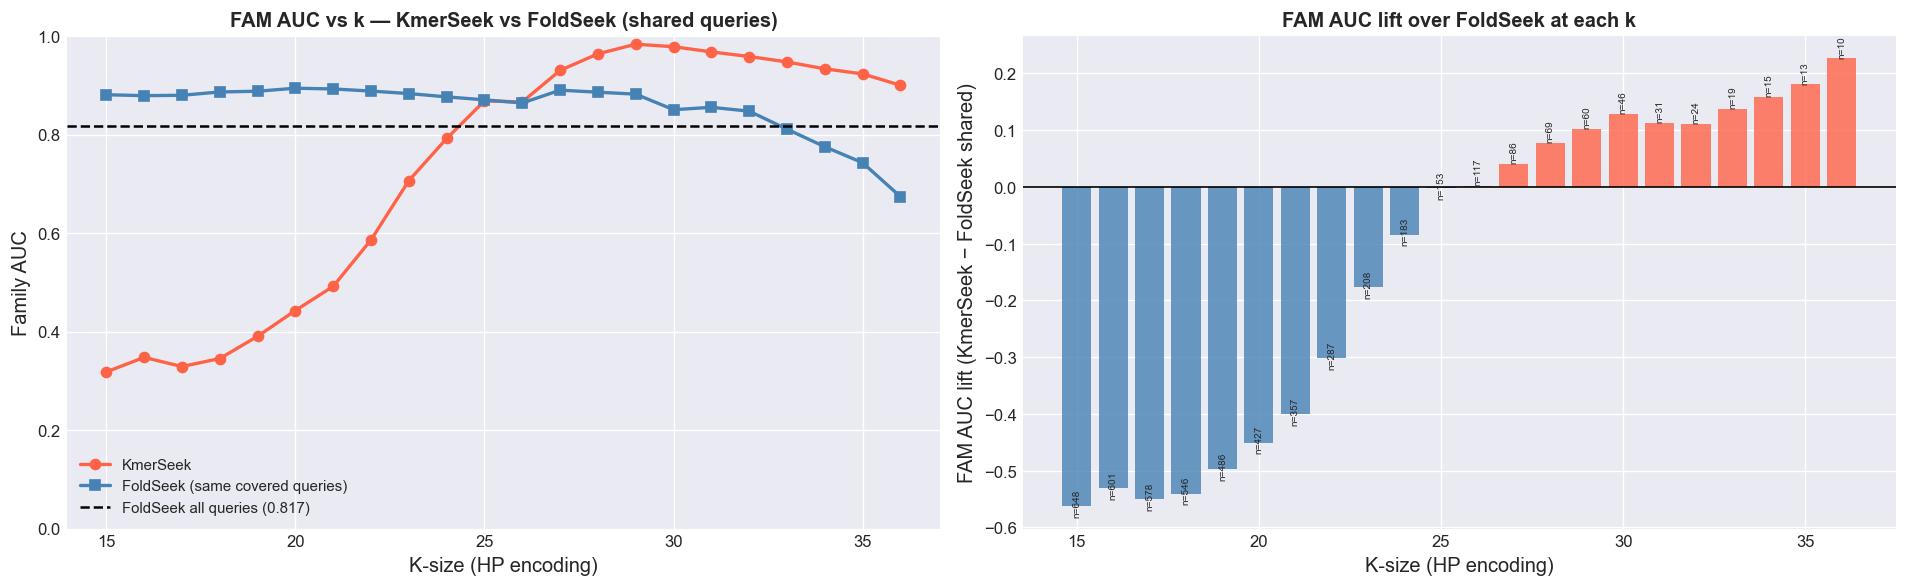

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ks   = lift_df['ksize'].to_numpy()
km_f = lift_df['km_fam'].to_numpy()
fs_f = lift_df['fs_fam_shared'].to_numpy()
lift = lift_df['lift'].to_numpy()

ax = axes[0]
ax.plot(ks, km_f, 'o-', color='tomato',    lw=2, ms=6, label='KmerSeek')
ax.plot(ks, fs_f, 's-', color='steelblue', lw=2, ms=6, label='FoldSeek (same covered queries)')
ax.axhline(sensitivity_stats(foldseek, 'FAM')[2], color='black', ls='--', lw=1.5,
           label=f'FoldSeek all queries ({sensitivity_stats(foldseek,"FAM")[2]:.3f})')
ax.set_xlabel('K-size (HP encoding)', fontsize=12)
ax.set_ylabel('Family AUC', fontsize=12)
ax.set_title('FAM AUC vs k — KmerSeek vs FoldSeek (shared queries)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0, 1)

ax = axes[1]
ax.bar(ks, lift, color=np.where(lift > 0, 'tomato', 'steelblue'), alpha=0.8)
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('K-size (HP encoding)', fontsize=12)
ax.set_ylabel('FAM AUC lift (KmerSeek − FoldSeek shared)', fontsize=12)
ax.set_title('FAM AUC lift over FoldSeek at each k', fontsize=12, fontweight='bold')
n_cov = lift_df['n_cov'].to_numpy()
for xi, ki, li, ni in zip(range(len(ks)), ks, lift, n_cov):
    ax.text(ki, li + (0.005 if li >= 0 else -0.015), f'n={ni}', ha='center', fontsize=6, rotation=90)
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_lift_across_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary for paper

In [13]:
print('=' * 80)
print('SUMMARY: Family-level AUC mechanism analysis')
print('=' * 80)

print(f'''
1. HEAD-TO-HEAD (k={K_FAM}, excl. gray zone):
   KmerSeek FAM AUC — own covered queries (n={n_km_total:,}): {km_fam_own:.4f}
   KmerSeek FAM AUC — matched to benchmark (n={len(covered):,}):  {km_fam:.4f}
   FoldSeek FAM AUC — all queries (n={foldseek["NAME"].n_unique():,}):          {fs_fam:.4f}
   FoldSeek FAM AUC — same {len(covered):,} covered queries:         {fsc_fam:.4f}
   Lift (KmerSeek − FoldSeek, matched queries):   {km_fam - fsc_fam:+.4f}

   Coverage note: {n_km_total:,} total covered; {len(covered):,} overlap with benchmark
   ({n_km_total - len(covered):,} KmerSeek-only queries outside FoldSeek's 40%-id benchmark).
   The 1.1% benchmark coverage reflects a deliberate niche: KmerSeek targets
   HP-pattern-rich families, not random SCOPe40 queries.

2. SELECTION BIAS:
   Covered queries (benchmark): {len(covered):,} ({100*len(covered)/len(ref_queries):.1f}% of benchmark)
   Median family peers (covered):   {np.median(peers_covered):.0f}
   Median family peers (uncovered): {np.median(peers_uncovered):.0f}
   Mann-Whitney p (covered > uncovered): {pval:.4f}
   → Covered queries have larger families, consistent with HP k-mer recall
     being driven by hydrophobic-pattern conservation across family members.

3. WHERE KMERSEEK OUTRANKS FOLDSEEK (per-query FAM sensitivity):
   KmerSeek > FoldSeek: {len(km_beats_names):,} queries
   FoldSeek > KmerSeek: {len(fs_beats_names):,} queries
   Tied:                {len(tied_names):,} queries
   Top classes where KmerSeek wins: {sorted(cnt_km_b, key=lambda c: -cnt_km_b[c])[:3]}

4. SEQUENCE IDENTITY (run section 8 for numbers):
   Window identity at HP k-mer loci — answers "what zone are the wins in?"

5. FOLDSEEK FAILURE MODE (run section 9 for numbers):
   FAM/SFAM ratio on KM-winning queries — diagnoses whether FoldSeek is
   placing cross-family or cross-fold FPs above family TPs.
''')

SUMMARY: Family-level AUC mechanism analysis

1. HEAD-TO-HEAD (k=29, excl. gray zone):
   KmerSeek FAM AUC — own covered queries (n=164): 0.9909
   KmerSeek FAM AUC — matched to benchmark (n=60):  0.9833
   FoldSeek FAM AUC — all queries (n=5,713):          0.8169
   FoldSeek FAM AUC — same 60 covered queries:         0.8819
   Lift (KmerSeek − FoldSeek, matched queries):   +0.1014

   Coverage note: 164 total covered; 60 overlap with benchmark
   (104 KmerSeek-only queries outside FoldSeek's 40%-id benchmark).
   The 1.1% benchmark coverage reflects a deliberate niche: KmerSeek targets
   HP-pattern-rich families, not random SCOPe40 queries.

2. SELECTION BIAS:
   Covered queries (benchmark): 60 (1.1% of benchmark)
   Median family peers (covered):   16
   Median family peers (uncovered): 9
   Mann-Whitney p (covered > uncovered): 0.0004
   → Covered queries have larger families, consistent with HP k-mer recall
     being driven by hydrophobic-pattern conservation across family member

## 8. Sequence identity of KmerSeek TPs

Addresses reviewer question: *"If your HP wins are at 30–60% identity, you're in 'above BLAST, below 3Di' niche. If <30%, you beat structure in the twilight zone."*

HP k-mer matched windows (`query_subseq` / `target_subseq`) have the same length (k-mer windows), so we compute **ungapped window identity**: fraction of positions with identical residues.
Note: this is local window identity at the matched HP locus, not global domain identity.

In [14]:
def window_identity(q: str, t: str) -> float:
    """Ungapped identity: fraction of identical residues over the shorter window."""
    n = min(len(q), len(t))
    if n == 0:
        return float('nan')
    return sum(a == b for a, b in zip(q, t)) / n

# Compute for all Bonf-filtered pairs, grouped by SCOP level
seqid_rows = []
for row in ev_filt_seq.iter_rows(named=True):
    q, t = row.get('query_subseq', ''), row.get('target_subseq', '')
    if not q or not t:
        continue
    seqid_rows.append({
        'query_domain':    row['query_domain'],
        'target_domain':   row['target_domain'],
        'same_family':     row['same_family'],
        'same_superfamily':row['same_superfamily'],
        'same_fold':       row['same_fold'],
        'window_identity': window_identity(q, t),
    })

seqid_df = pl.DataFrame(seqid_rows)
print(f'Total pairs with seq data: {len(seqid_df):,}')

for level_col, label in [('same_family', 'Family TPs'), ('same_superfamily', 'Sfam TPs'), ('same_fold', 'Fold TPs')]:
    sub = seqid_df.filter(pl.col(level_col) == True)['window_identity'].drop_nulls()
    print(f'{label:18s}: n={len(sub):4d}  median={sub.median():.1%}  mean={sub.mean():.1%}  '
          f'<30%:{(sub < 0.30).sum():4d}  30-60%:{((sub>=0.30)&(sub<0.60)).sum():4d}  ≥60%:{(sub>=0.60).sum():4d}')
fps = seqid_df.filter(
    (pl.col('same_family') == False) & (pl.col('same_superfamily') == False)
)['window_identity'].drop_nulls()
print(f'{"FPs (diff sfam)":18s}: n={len(fps):4d}  median={fps.median():.1%}  mean={fps.mean():.1%}')

Total pairs with seq data: 785
Family TPs        : n= 172  median=54.4%  mean=54.9%  <30%:   4  30-60%: 109  ≥60%:  59
Sfam TPs          : n= 287  median=54.3%  mean=54.1%  <30%:  10  30-60%: 187  ≥60%:  90
Fold TPs          : n= 298  median=53.5%  mean=52.9%  <30%:  19  30-60%: 189  ≥60%:  90
FPs (diff sfam)   : n= 498  median=12.1%  mean=12.5%


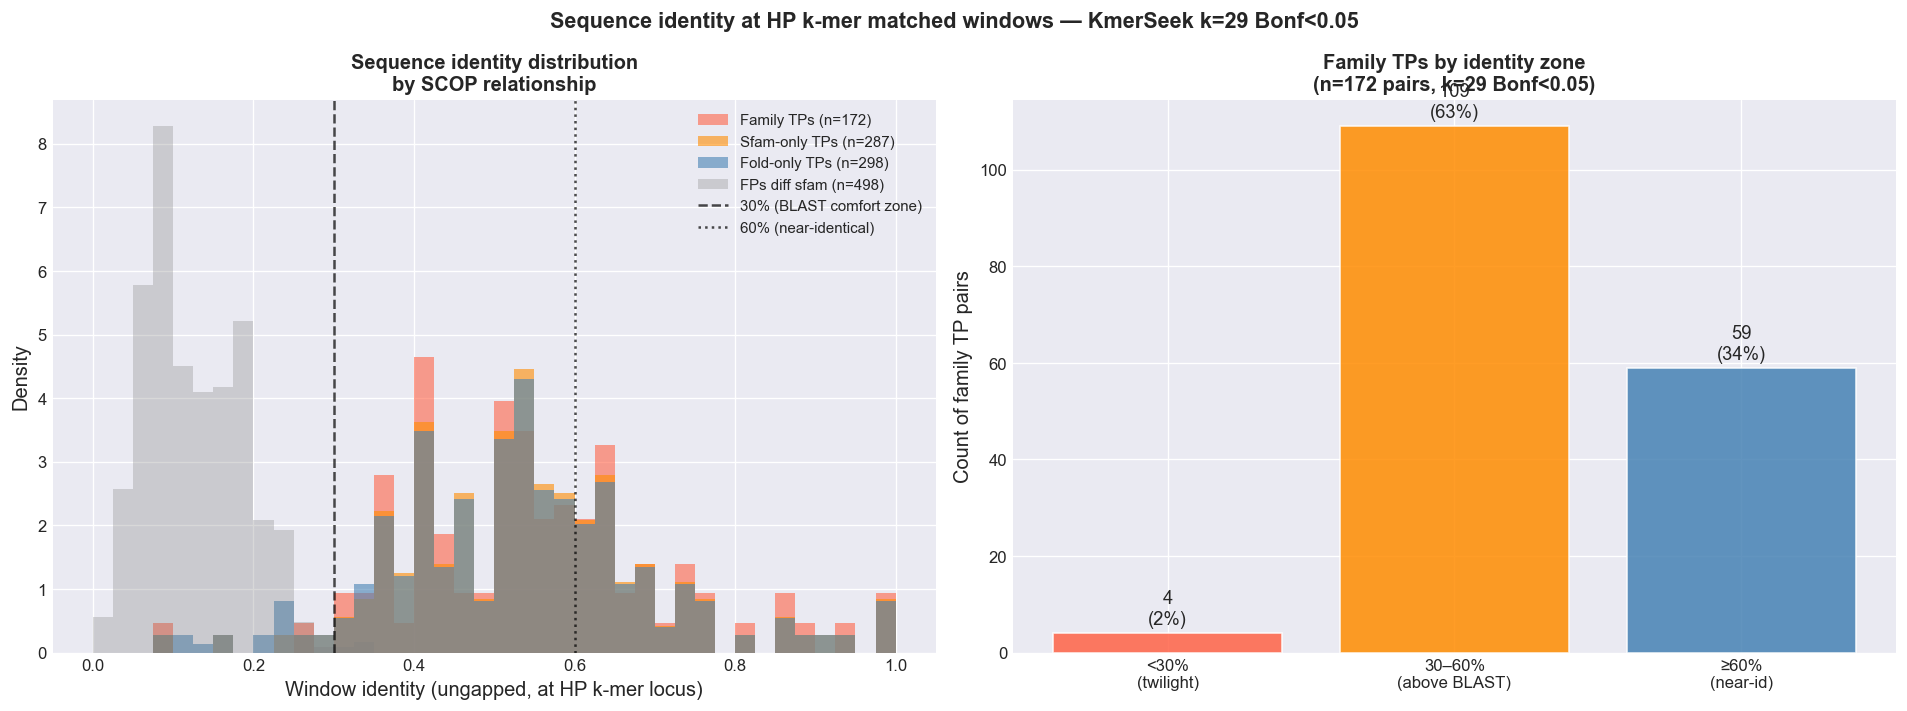


Key framing: 4 / 172 family TPs (2%) are in twilight zone (<30% id)
  109 / 172 (63%) in above-BLAST zone (30–60% id)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: distribution by SCOP level
ax = axes[0]
BINS = np.linspace(0, 1, 41)
level_specs = [
    ('same_family',     'Family TPs',    'tomato'),
    ('same_superfamily','Sfam-only TPs', 'darkorange'),
    ('same_fold',       'Fold-only TPs', 'steelblue'),
]
for col, label, color in level_specs:
    vals = seqid_df.filter(pl.col(col) == True)['window_identity'].drop_nulls().to_numpy()
    if len(vals) > 0:
        ax.hist(vals, bins=BINS, density=True, alpha=0.6, color=color, label=f'{label} (n={len(vals)})')
fps_vals = fps.to_numpy()
ax.hist(fps_vals, bins=BINS, density=True, alpha=0.3, color='grey', label=f'FPs diff sfam (n={len(fps_vals)})')
ax.axvline(0.30, color='black', ls='--', lw=1.5, alpha=0.7, label='30% (BLAST comfort zone)')
ax.axvline(0.60, color='black', ls=':',  lw=1.5, alpha=0.7, label='60% (near-identical)')
ax.set_xlabel('Window identity (ungapped, at HP k-mer locus)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Sequence identity distribution\nby SCOP relationship', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Right: identity zone breakdown for family TPs
ax = axes[1]
fam_tp_ids = seqid_df.filter(pl.col('same_family') == True)['window_identity'].drop_nulls().to_numpy()
zones      = ['<30%\n(twilight)', '30–60%\n(above BLAST)', '≥60%\n(near-id)']
zone_counts = [
    (fam_tp_ids < 0.30).sum(),
    ((fam_tp_ids >= 0.30) & (fam_tp_ids < 0.60)).sum(),
    (fam_tp_ids >= 0.60).sum(),
]
colors_z = ['tomato', 'darkorange', 'steelblue']
bars = ax.bar(zones, zone_counts, color=colors_z, alpha=0.85, edgecolor='white')
for bar, cnt in zip(bars, zone_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{cnt}\n({100*cnt/len(fam_tp_ids):.0f}%)', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Count of family TP pairs', fontsize=12)
ax.set_title(f'Family TPs by identity zone\n(n={len(fam_tp_ids)} pairs, k={K_FAM} Bonf<{BONF_THRESHOLD})',
             fontsize=12, fontweight='bold')

plt.suptitle('Sequence identity at HP k-mer matched windows — KmerSeek k=29 Bonf<0.05',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_seqid_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nKey framing: {(fam_tp_ids < 0.30).sum()} / {len(fam_tp_ids)} family TPs '
      f'({100*(fam_tp_ids < 0.30).sum()/len(fam_tp_ids):.0f}%) are in twilight zone (<30% id)')
print(f'  {((fam_tp_ids >= 0.30) & (fam_tp_ids < 0.60)).sum()} / {len(fam_tp_ids)} '
      f'({100*((fam_tp_ids >= 0.30) & (fam_tp_ids < 0.60)).sum()/len(fam_tp_ids):.0f}%) '
      f'in above-BLAST zone (30–60% id)')

## 9. FoldSeek failure mode on KM-winning queries

For the 33 queries where `km_fam > fs_fam`: does FoldSeek place a **cross-fold hit above family TPs** (3Di scoring failure), or does it just **rank family TPs lower** (calibration difference)?

- If FoldSeek's first FP is a different-family same-fold or cross-fold hit → structural scoring is mislead
- If FoldSeek has no FPs but lower sensitivity → calibration/threshold issue

In [16]:
from scope_kmerseek_utils import BENCH_DIR, load_baselines

# Load FoldSeek raw eval-format ROCX — we need the per-hit ordering to find first FP
# FoldSeek ROCX has columns: NAME, SCOP, FAM, SFAM, FOLD, CLASS (sensitivity at first FP)
# But we need per-hit rank. We'll use fs_cov (already restricted to 33+27 = 60 queries).
#
# FoldSeek ROCX 'FAM' column = sensitivity at first FP.  If FAM < 1.0, FoldSeek placed
# at least one FP before exhausting all family TPs.
# We can check the *type* of first FP from the ROCX SCOP column of non-TP hits.
# However FoldSeek ROCX only stores the query's own SCOP, not the hit SCOP.
# Instead, load the FoldSeek ROCX DataFrame directly and look up each winning query.

# For a proxy: compare FAM vs SFAM sensitivity curves on the 33 KM-winning queries.
# If FoldSeek's SFAM sensitivity is low too → its first FP comes from a different superfamily
# (cross-fold), which is a harder structural case.
# If SFAM sensitivity is high but FAM is low → FoldSeek is confused within the same superfamily.

fs_km_wins = foldseek.filter(pl.col('NAME').is_in(km_beats_names))
km_km_wins = km_rocx_r.filter(pl.col('NAME').is_in(km_beats_names))

_, _, fs_fam_wins  = sensitivity_stats(fs_km_wins, 'FAM')
_, _, fs_sfam_wins = sensitivity_stats(fs_km_wins, 'SFAM')
_, _, km_fam_wins  = sensitivity_stats(km_km_wins, 'FAM')

print('=== FoldSeek on the 33 KM-winning queries ===')
print(f'  FoldSeek FAM  sensitivity: {fs_fam_wins:.4f}')
print(f'  FoldSeek SFAM sensitivity: {fs_sfam_wins:.4f}')
print(f'  KmerSeek FAM  sensitivity: {km_fam_wins:.4f}')
print()

# Per-query breakdown: does FoldSeek reach FAM=1.0 (finds all TPs before first FP)?
# FAM col in ROCX = sensitivity at first FP = fraction of family TPs above first FP
fs_wins_per_q = fs_km_wins.select(['NAME', 'FAM', 'SFAM', 'SCOP'])
km_wins_per_q = km_km_wins.select(['NAME', 'FAM']).rename({'FAM': 'km_fam'})
wins_merged   = fs_wins_per_q.join(km_wins_per_q, on='NAME', how='left')

perfect_fs  = wins_merged.filter(pl.col('FAM') == 1.0)
imperfect_fs = wins_merged.filter(pl.col('FAM') < 1.0)
no_tp_fs     = wins_merged.filter(pl.col('FAM') == 0.0)

print(f'FoldSeek finds ALL family TPs before first FP (FAM=1.0): {len(perfect_fs):,}')
print(f'FoldSeek reaches partial sensitivity (0 < FAM < 1):      {len(imperfect_fs) - len(no_tp_fs):,}')
print(f'FoldSeek places a FP before any family TP (FAM=0):       {len(no_tp_fs):,}')
print()
print('Per-query detail (FAM, SFAM, SCOP class) for imperfect/zero FoldSeek:')
print(wins_merged.filter(pl.col('FAM') < 1.0).sort('FAM').select(['NAME','FAM','SFAM','SCOP','km_fam']))

=== FoldSeek on the 33 KM-winning queries ===
  FoldSeek FAM  sensitivity: 0.7855
  FoldSeek SFAM sensitivity: 0.6142
  KmerSeek FAM  sensitivity: 0.9697

FoldSeek finds ALL family TPs before first FP (FAM=1.0): 0
FoldSeek reaches partial sensitivity (0 < FAM < 1):      33
FoldSeek places a FP before any family TP (FAM=0):       0

Per-query detail (FAM, SFAM, SCOP class) for imperfect/zero FoldSeek:
shape: (33, 5)
┌─────────┬──────────┬──────────┬──────────┬────────┐
│ NAME    ┆ FAM      ┆ SFAM     ┆ SCOP     ┆ km_fam │
│ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---    │
│ str     ┆ f64      ┆ f64      ┆ str      ┆ f64    │
╞═════════╪══════════╪══════════╪══════════╪════════╡
│ d2uy2a_ ┆ 0.128205 ┆ 0.21875  ┆ c.1.8.0  ┆ 1.0    │
│ d3mu7a_ ┆ 0.307692 ┆ 0.291667 ┆ c.1.8.0  ┆ 1.0    │
│ d5vaaa1 ┆ 0.484127 ┆ 0.318584 ┆ b.1.1.0  ┆ 1.0    │
│ d2w59a1 ┆ 0.492063 ┆ 0.318584 ┆ b.1.1.0  ┆ 1.0    │
│ d4gbua_ ┆ 0.666667 ┆ 0.555556 ┆ c.1.4.1  ┆ 1.0    │
│ …       ┆ …        ┆ …        ┆ …      

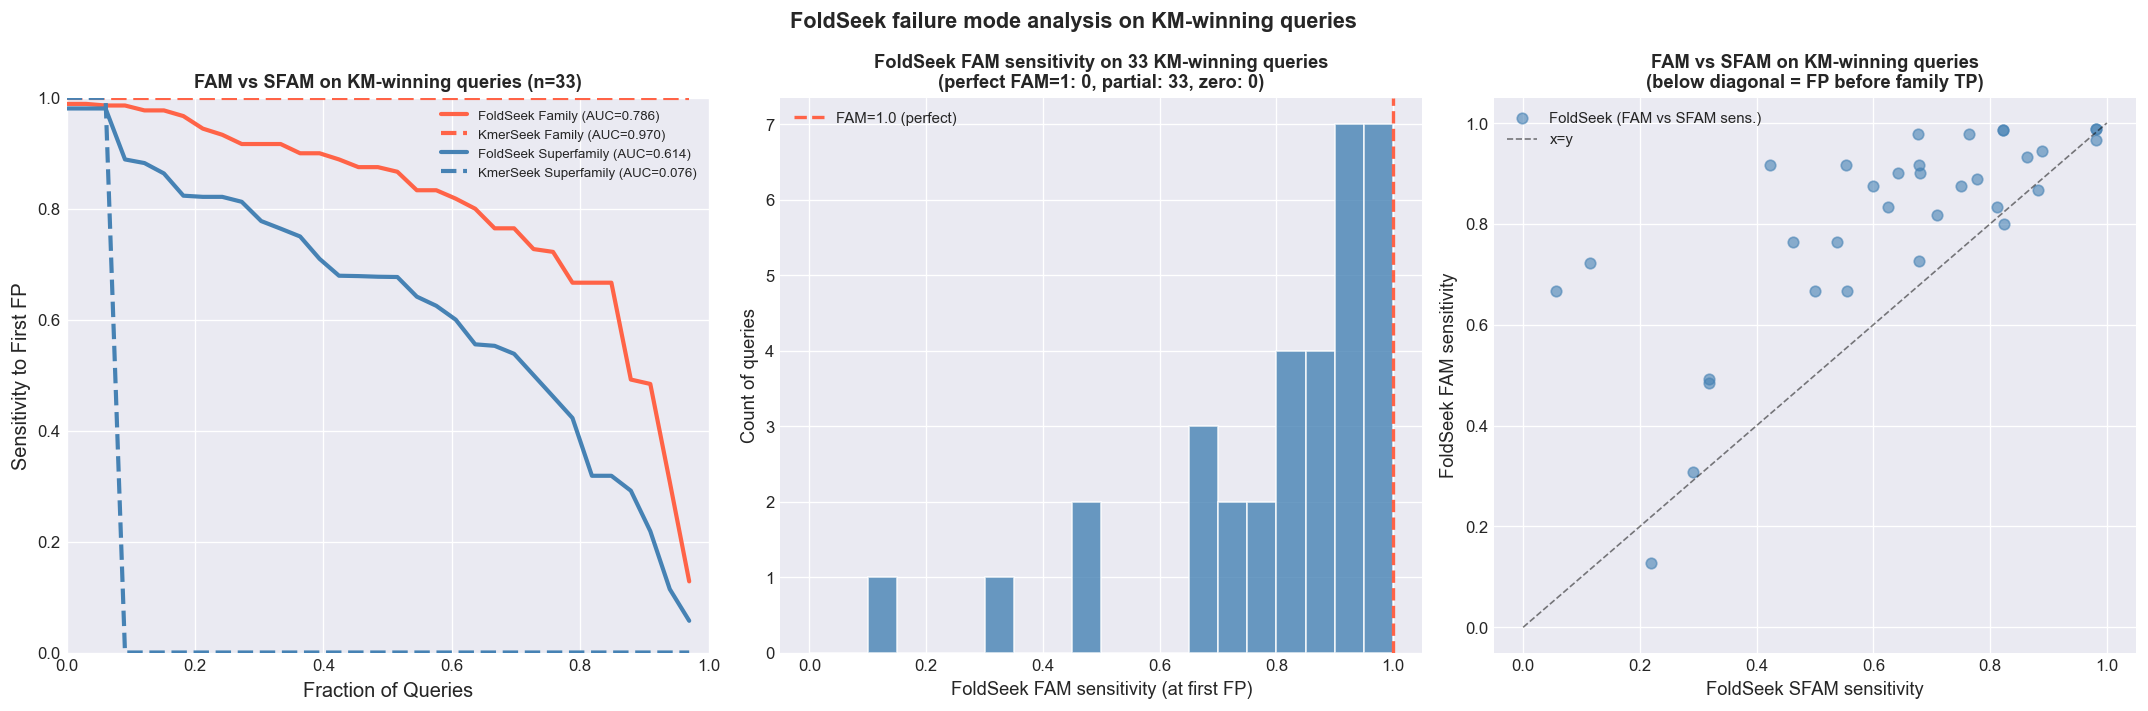

Queries where FoldSeek SFAM < FAM (first FP is cross-family, same-sfam): 4 / 33
Queries where FoldSeek SFAM < 0.5 (FP is cross-sfam/fold level):          8 / 33


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: FAM vs SFAM AUC on KM-winning queries
ax = axes[0]
for lc, ll, color in [('FAM', 'Family', 'tomato'), ('SFAM', 'Superfamily', 'steelblue')]:
    frac, sens, auc = sensitivity_stats(fs_km_wins, lc)
    ax.plot(frac, sens, '-', color=color, lw=2.5, label=f'FoldSeek {ll} (AUC={auc:.3f})')
    frac, sens, auc = sensitivity_stats(km_km_wins, lc)
    ax.plot(frac, sens, '--', color=color, lw=2.5, label=f'KmerSeek {ll} (AUC={auc:.3f})')
ax.set_xlabel('Fraction of Queries', fontsize=12)
ax.set_ylabel('Sensitivity to First FP', fontsize=12)
ax.set_title(f'FAM vs SFAM on KM-winning queries (n={len(km_beats_names):,})',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Middle: FoldSeek FAM failure mode histogram
ax = axes[1]
fam_vals = fs_km_wins['FAM'].to_numpy()
bins = np.linspace(0, 1, 21)
ax.hist(fam_vals, bins=bins, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(1.0, color='tomato', ls='--', lw=2, label='FAM=1.0 (perfect)')
ax.set_xlabel('FoldSeek FAM sensitivity (at first FP)', fontsize=11)
ax.set_ylabel('Count of queries', fontsize=11)
ax.set_title(f'FoldSeek FAM sensitivity on 33 KM-winning queries\n'
             f'(perfect FAM=1: {len(perfect_fs)}, partial: {len(imperfect_fs)-len(no_tp_fs)}, zero: {len(no_tp_fs)})',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Right: scatter FAM vs SFAM to diagnose FP type
ax = axes[2]
ax.scatter(fs_km_wins['SFAM'].to_numpy(), fs_km_wins['FAM'].to_numpy(),
           alpha=0.6, s=40, color='steelblue', label='FoldSeek (FAM vs SFAM sens.)')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='x=y')
ax.set_xlabel('FoldSeek SFAM sensitivity', fontsize=11)
ax.set_ylabel('FoldSeek FAM sensitivity', fontsize=11)
ax.set_title('FAM vs SFAM on KM-winning queries\n(below diagonal = FP before family TP)',
             fontsize=11, fontweight='bold')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=9)

plt.suptitle('FoldSeek failure mode analysis on KM-winning queries',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_foldseek_failure_mode.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpret
n_cross_sfam_fps = wins_merged.filter((pl.col('FAM') < pl.col('SFAM'))).height
n_cross_fold_fps = wins_merged.filter(pl.col('SFAM') < 0.5).height
print(f'Queries where FoldSeek SFAM < FAM (first FP is cross-family, same-sfam): '
      f'{n_cross_sfam_fps} / {len(km_beats_names)}')
print(f'Queries where FoldSeek SFAM < 0.5 (FP is cross-sfam/fold level):          '
      f'{n_cross_fold_fps} / {len(km_beats_names)}')

## 10. Alignment viewer: 33 KM-winning queries by SCOPe class

Uses `print_kmer_alignments_by_class` from `scope_kmerseek_utils`.

In [18]:
from scope_kmerseek_utils import print_kmer_alignments_by_class, pct_id_sim

# Domain metadata
domains  = pl.read_csv(BENCH_DIR / 'scope_domains.tsv', separator='\t')
dom_map  = dict(zip(domains['domain_id'], domains['protein_name']))
scop_map = dict(zip(domains['domain_id'], domains['scop_id']))

# Prepare eval DataFrame: KM-winning queries, best TP hit per query
# ev_filt_seq has all 785 Bonf-filtered pairs; we want same_family TPs for the 33 KM-winning queries
km_wins_eval = (
    ev_filt_seq
    .filter(pl.col('query_domain').is_in(km_beats_names))
    .filter(pl.col('same_family') == True)
)
print(f'KM-winning family TP pairs available: {len(km_wins_eval):,} across {km_wins_eval["query_domain"].n_unique():,} queries')

# Add moltype_seq from the full eval (HP encoding of the window)
# moltype_seq is not in EVAL_USECOLS; load it separately
ev_hp = load_eval(K_FAM, columns=['query_domain', 'target_domain', 'moltype_seq', 'region_length',
                                   'query_start', 'target_start'])
km_wins_eval = km_wins_eval.join(ev_hp, on=['query_domain', 'target_domain'], how='left')
del ev_hp; gc.collect()

print_kmer_alignments_by_class(
    eval_df       = km_wins_eval,
    query_names   = km_beats_names,
    dom_map       = dom_map,
    scop_map      = scop_map,
    overlap_disorder = None,  # computed in section 11; re-run after disorder cell
    sort_by       = 'poisson_pvalue',
    best_hit_only = True,
    class_descriptions = SCOPE_CLASS_DESCRIPTIONS,
)

KM-winning family TP pairs available: 35 across 33 queries

  SCOPe CLASS A — All alpha proteins  (5 queries)
  QUERY:  d1c20a_  SCOP=a.4.3.1  DNA-binding domain from the dead ringer protein
  TARGET: d2cxya_  SCOP=a.4.3.1  automated matches
  pval=1.34e-13  jaccard=0.0276  containment=0.0500  region_len=33  %id=42.4%  %sim=75.8%

    Q[  25] FLDDLFSFMQKRGTPINRLPIMAKSVLDLYELY
            ::|...:||::||:|::.||.::|..|||:.||
    T[  18] WVDRYLTFMEERGSPVSSLPAVGKKPLDLFRLY
    HP      hhpphhphhppphphhpphhhhhpphhphhphh

  --------------------------------------------------------------------------------------------------
  QUERY:  d1oqpa1  SCOP=a.39.1.5  Caltractin (centrin 2)
  TARGET: d3fwba_  SCOP=a.39.1.5  automated matches
  pval=0.00e+00  jaccard=0.0488  containment=0.1702  region_len=36  %id=72.2%  %sim=91.7%

    Q[  10] KAFRLFDDDNSGTITIKDLRRVAKELGENLTEEELQ
            :||.|||||::|.|:||:||||||||||:||:|||.
    T[  91] RAFQLFDDDHTGKISIKNLRRVAKELGETLTDEELR
    HP      phhphhppppphphphpphpph

## 11. Protein disorder: KM-winning vs tied queries

Computes full-protein disorder with metapredict for the 60 covered queries,
then compares KM-winning (33) vs tied (27) at the overlap window level.

In [19]:
import metapredict as meta
from scipy.stats import mannwhitneyu

FASTA_PATH = '/Users/olga/data/scope/astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa'
IDR_THRESHOLD = 0.5

# metapredict only accepts the 20 standard amino acids — replace anything else with 'G'
_VALID_AA = set('ACDEFGHIKLMNPQRSTVWY')
def clean_seq(seq: str) -> str:
    return ''.join(aa if aa in _VALID_AA else 'G' for aa in seq.upper())

def parse_fasta(path):
    seqs = {}
    cur_id, buf = None, []
    with open(path) as fh:
        for line in fh:
            line = line.rstrip()
            if line.startswith('>'):
                if cur_id:
                    seqs[cur_id] = ''.join(buf)
                cur_id = line[1:].split()[0]
                buf = []
            else:
                buf.append(line)
    if cur_id:
        seqs[cur_id] = ''.join(buf)
    return seqs

print('Parsing FASTA...')
all_seqs = parse_fasta(FASTA_PATH)
print(f'  {len(all_seqs):,} sequences loaded')

# Compute disorder for covered queries only (60 proteins)
print(f'Computing disorder for {len(covered):,} covered queries...')
disorder_full    = {}   # {domain: mean full-protein disorder}
disorder_overlap = {}   # {domain: mean disorder at HP k-mer overlap window}

for qid in covered:
    raw_seq = all_seqs.get(qid)
    if not raw_seq:
        continue
    seq = clean_seq(raw_seq)
    scores = meta.predict_disorder(seq)
    disorder_full[qid] = float(np.mean(scores))

    # Overlap window: best Bonf-sig hit for this query → use query_start/query_end
    q_hits = ev_filt_seq.filter(pl.col('query_domain') == qid).sort('poisson_pvalue')
    if q_hits.height > 0:
        row = q_hits.row(0, named=True)
        qs = max(0, row.get('query_start', 0))
        qe = min(len(scores), row.get('query_end', len(seq)))
        if qs < qe:
            disorder_overlap[qid] = float(np.mean(scores[qs:qe]))

print(f'  Full-protein disorder computed: {len(disorder_full):,}')
print(f'  Overlap disorder computed:       {len(disorder_overlap):,}')

# Compare KM-winning vs tied
wins_full = [disorder_full[q]    for q in km_beats_names if q in disorder_full]
tied_full = [disorder_full[q]    for q in tied_names     if q in disorder_full]
wins_ov   = [disorder_overlap[q] for q in km_beats_names if q in disorder_overlap]
tied_ov   = [disorder_overlap[q] for q in tied_names     if q in disorder_overlap]

for label, w, t in [('Full-protein disorder', wins_full, tied_full),
                     ('Overlap disorder',      wins_ov,   tied_ov)]:
    if len(w) > 1 and len(t) > 1:
        _, p = mannwhitneyu(w, t, alternative='two-sided')
        print(f'{label}:')
        print(f'  KM-winning (n={len(w)}): mean={np.mean(w):.3f}  median={np.median(w):.3f}')
        print(f'  Tied       (n={len(t)}): mean={np.mean(t):.3f}  median={np.median(t):.3f}')
        print(f'  Mann-Whitney p (two-sided): {p:.4f}')

Parsing FASTA...
  15,177 sequences loaded
Computing disorder for 60 covered queries...


  Full-protein disorder computed: 60
  Overlap disorder computed:       60
Full-protein disorder:
  KM-winning (n=33): mean=0.124  median=0.112
  Tied       (n=27): mean=0.073  median=0.056
  Mann-Whitney p (two-sided): 0.0028
Overlap disorder:
  KM-winning (n=33): mean=0.084  median=0.064
  Tied       (n=27): mean=0.046  median=0.035
  Mann-Whitney p (two-sided): 0.0057


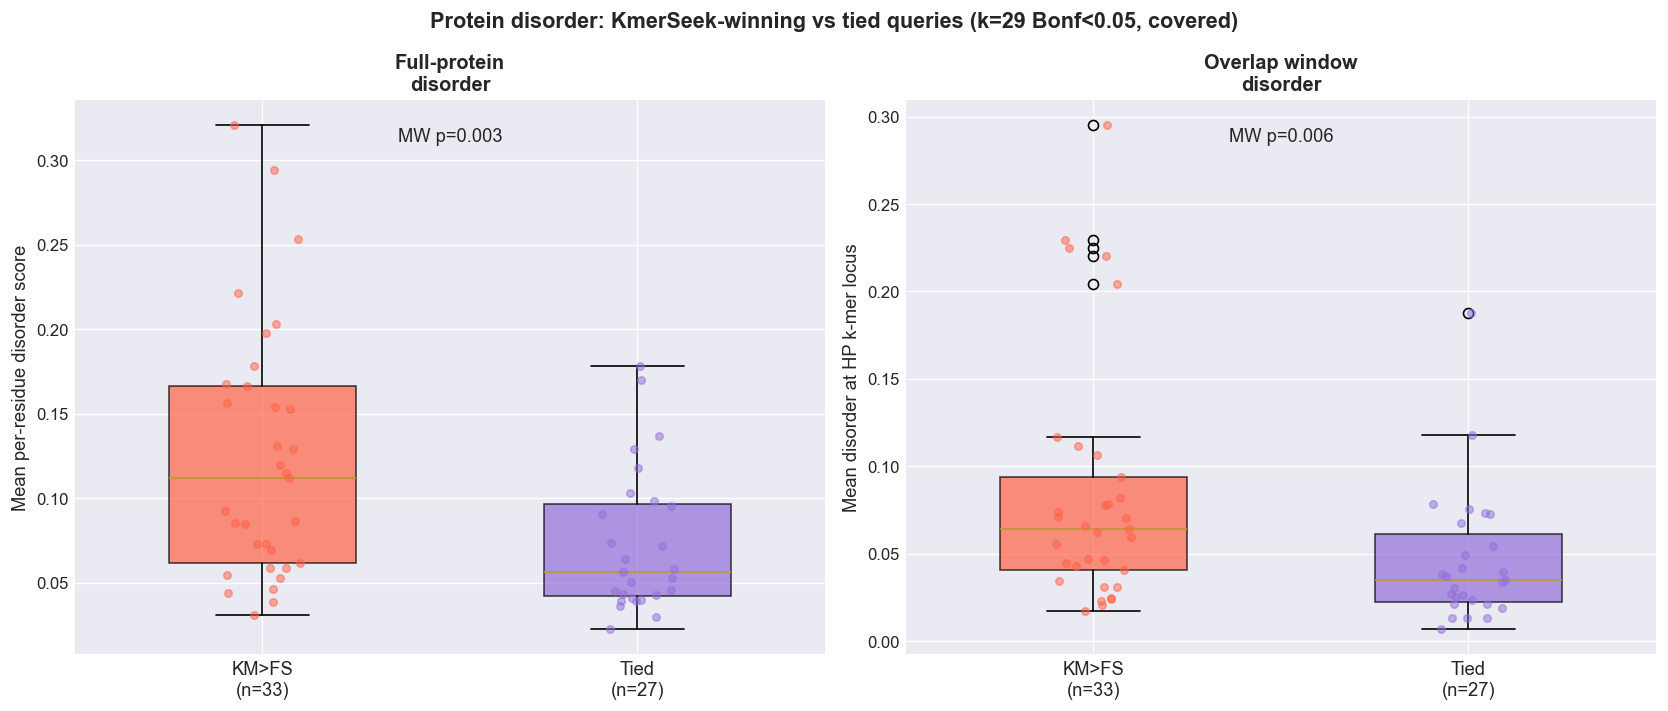


Re-running alignment viewer with overlap disorder scores...

  SCOPe CLASS A — All alpha proteins  (5 queries)
  QUERY:  d1c20a_  SCOP=a.4.3.1  DNA-binding domain from the dead ringer protein
  TARGET: d2cxya_  SCOP=a.4.3.1  automated matches
  pval=1.34e-13  jaccard=0.0276  containment=0.0500  region_len=33  %id=42.4%  %sim=75.8%  disorder=0.04

    Q[  25] FLDDLFSFMQKRGTPINRLPIMAKSVLDLYELY
            ::|...:||::||:|::.||.::|..|||:.||
    T[  18] WVDRYLTFMEERGSPVSSLPAVGKKPLDLFRLY
    HP      hhpphhphhppphphhpphhhhhpphhphhphh

  --------------------------------------------------------------------------------------------------
  QUERY:  d1oqpa1  SCOP=a.39.1.5  Caltractin (centrin 2)
  TARGET: d3fwba_  SCOP=a.39.1.5  automated matches
  pval=0.00e+00  jaccard=0.0488  containment=0.1702  region_len=36  %id=72.2%  %sim=91.7%  disorder=0.23

    Q[  10] KAFRLFDDDNSGTITIKDLRRVAKELGENLTEEELQ
            :||.|||||::|.|:||:||||||||||:||:|||.
    T[  91] RAFQLFDDDHTGKISIKNLRRVAKELGETLTDEELR
  

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, w, t, ylabel) in zip(axes, [
    ('Full-protein\ndisorder', wins_full, tied_full, 'Mean per-residue disorder score'),
    ('Overlap window\ndisorder', wins_ov, tied_ov,   'Mean disorder at HP k-mer locus'),
]):
    data_box = [w, t]
    bp = ax.boxplot(data_box, patch_artist=True, widths=0.5, showfliers=True,
                    positions=[0, 1])
    for patch, color in zip(bp['boxes'], ['tomato', 'mediumpurple']):
        patch.set_facecolor(color); patch.set_alpha(0.7)

    # Overlay individual points
    for xi, vals, color in [(0, w, 'tomato'), (1, t, 'mediumpurple')]:
        jitter = np.random.default_rng(xi).uniform(-0.1, 0.1, len(vals))
        ax.scatter(np.full(len(vals), xi) + jitter, vals,
                   alpha=0.5, s=20, color=color, zorder=5)

    if len(w) > 1 and len(t) > 1:
        _, p = mannwhitneyu(w, t, alternative='two-sided')
        ax.text(0.5, 0.95, f'MW p={p:.3f}', ha='center', va='top',
                transform=ax.transAxes, fontsize=11)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'KM>FS\n(n={len(w)})', f'Tied\n(n={len(t)})'], fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')

plt.suptitle('Protein disorder: KmerSeek-winning vs tied queries (k=29 Bonf<0.05, covered)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_disorder_km_wins_vs_tied.png', dpi=150, bbox_inches='tight')
plt.show()

# Re-run section 10 alignment viewer WITH disorder scores
print('\nRe-running alignment viewer with overlap disorder scores...')
print_kmer_alignments_by_class(
    eval_df          = km_wins_eval,
    query_names      = km_beats_names,
    dom_map          = dom_map,
    scop_map         = scop_map,
    overlap_disorder = disorder_overlap,
    sort_by          = 'poisson_pvalue',
    best_hit_only    = True,
    class_descriptions = SCOPE_CLASS_DESCRIPTIONS,
)

## 12. Per-class family sensitivity (survival-function style)

Replicates the FoldSeek paper figure style: one panel per SCOPe class, x=sensitivity at first FP, y=fraction of queries achieving that sensitivity.
KmerSeek covers only ~1.1% of queries; uncovered queries are treated as FAM=0.


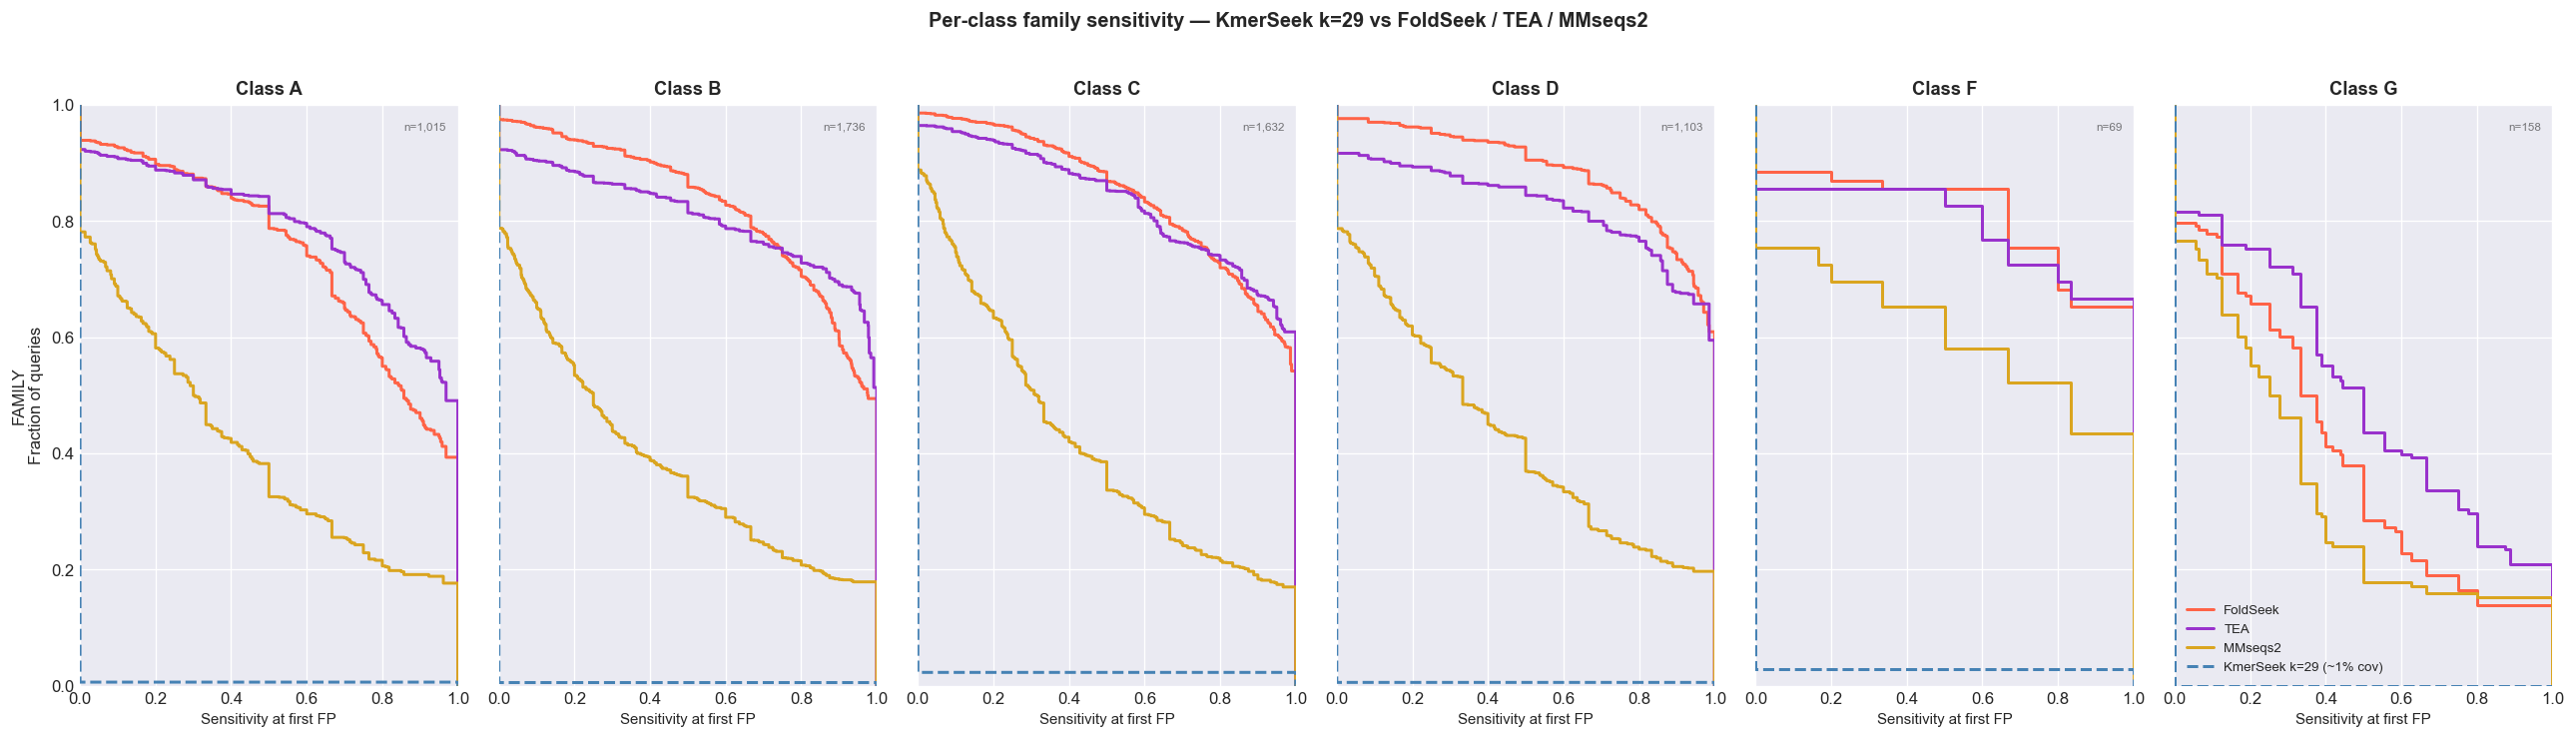

In [54]:
from collections import defaultdict

plt.style.use('seaborn-v0_8-darkgrid')   # reset any leftover dark_background style

# Per-query FAM for each method
def per_query_fam(rocx_df):
    return dict(zip(rocx_df['NAME'].to_list(), rocx_df['FAM'].to_list()))

mmseqs = pl.read_csv(
    Path('/Users/olga/code/2024-kmerseek-analysis/data/tea_scope40_rocx_files/mmseqs.rocx'),
    separator='\t',
)

fs_fam_dict  = per_query_fam(foldseek)
tea_fam_dict = per_query_fam(tea_all)
mm_fam_dict  = per_query_fam(mmseqs)
km_fam_dict  = per_query_fam(km_rocx)   # 164 covered; rest treated as 0

# Query → SCOPe class
cls_lookup = dict(
    foldseek.with_columns(pl.col('SCOP').str.slice(0, 1).alias('cls'))
            .select(['NAME', 'cls']).iter_rows()
)
cls_to_queries = defaultdict(set)
for q, c in cls_lookup.items():
    cls_to_queries[c].add(q)
scop_classes = sorted(cls_to_queries.keys())

def survival_curve(fam_dict, queries):
    """y(x) = fraction of queries with FAM >= x. Absent queries treated as FAM=0."""
    vals = np.sort([fam_dict.get(q, 0.0) for q in queries])
    n = len(vals)
    x = np.concatenate([[0.0], vals, [1.0 + 1e-9]])
    y = np.concatenate([[1.0], 1.0 - np.arange(1, n + 1) / n, [0.0]])
    return x, y

# ---- Plot ----
n_cls = len(scop_classes)
fig, axes = plt.subplots(1, n_cls, figsize=(3.6 * n_cls, 6), sharey=True)
fig.subplots_adjust(wspace=0.06)

METHODS = [
    ('FoldSeek',                      fs_fam_dict,  'tomato',      '-',  1.8),
    ('TEA',                           tea_fam_dict, 'darkorchid',  '-',  1.8),
    ('MMseqs2',                       mm_fam_dict,  'goldenrod',   '-',  1.8),
    (f'KmerSeek k={K_FAM} (~1% cov)', km_fam_dict, 'steelblue',  '--', 1.8),
]

for i, (ax, cls) in enumerate(zip(axes, scop_classes)):
    queries = cls_to_queries[cls]
    n_q = len(queries)
    ax.set_title(f'Class {cls.upper()}', fontsize=11, fontweight='bold')

    for label, fam_dict, color, ls, lw in METHODS:
        x, y = survival_curve(fam_dict, queries)
        ax.step(x, y, where='post', color=color, lw=lw, ls=ls,
                label=label if i == n_cls - 1 else '_nolegend_')

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Sensitivity at first FP', fontsize=9)
    if i == 0:
        ax.set_ylabel('FAMILY\nFraction of queries', fontsize=10)
    ax.text(0.97, 0.97, f'n={n_q:,}', transform=ax.transAxes,
            fontsize=7, ha='right', va='top', alpha=0.6)

axes[-1].legend(loc='lower left', fontsize=8)

plt.suptitle(f'Per-class family sensitivity — KmerSeek k={K_FAM} vs FoldSeek / TEA / MMseqs2',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_per_class_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Verdict

Section 7's printed summary is the headline; sections 8-12 qualify it in ways that change what can
be claimed.

**The +0.10 family AUC lift is real, head-to-head, and on 60 queries.** At k=29, kmerseek scores
0.9833 against FoldSeek's 0.8819 on the same 60 shared queries, a lift of +0.1014. Per query,
kmerseek ranks better on 33, ties on 27, and loses on 0. FoldSeek's headline 0.8169 over all 5,713
benchmark queries is not the right comparator and should not be used as one. The 60 shared queries
are 1.1% of the benchmark, with a further 104 covered queries that FoldSeek misses entirely.

**The lift only exists where n is small.** Across the k sweep it is negative at every k with
substantial coverage (k=15, n=648, lift -0.563; k=20, n=427, -0.451; k=24, n=183, -0.085), crosses
zero at k=25-26 (n=153 and 117), and is positive only from k=26 upward as n falls to 46, 24, then
10. The lift and the coverage collapse are the same curve read two ways. "Kmerseek beats FoldSeek at
family level" is true only at k where it answers for a few dozen queries.

**Coverage is not a random subsample.** Covered queries have a median of 16 family peers against 9
for uncovered ones (Mann-Whitney p=0.0004). Kmerseek reaches queries that sit in large families,
which is exactly where HP-pattern conservation across many family members gives it something to
match. That is a mechanism, and it is also a selection effect that inflates any AUC computed on the
covered set.

**The wins are not in the twilight zone, and this is the finding that most constrains the paper
claim.** Window identity at the matched HP loci for family true positives has median 54.4%, with
109/172 (63%) between 30% and 60% and only **4/172 (2%) below 30%**. False positives sit at median
12.1%, so the score does separate, but the true positives kmerseek recovers are mostly in the
above-BLAST, below-3Di band rather than the remote-homology regime. Any claim that HP patterning
survives deep sequence divergence needs evidence from somewhere other than this notebook. Note also
that this is local identity inside a k-length matched window, not global domain identity, so it will
read higher than a domain-level number by construction.

**FoldSeek is not being fooled; it is ranking lower.** On the 33 kmerseek-winning queries, FoldSeek
reaches FAM 0.7855 and SFAM 0.6142 against kmerseek's 0.9697, but **zero of the 33 have FoldSeek
placing a false positive above every family true positive**, and all 33 are partial sensitivity.
Only 4/33 have a cross-family same-superfamily first FP and 8/33 a cross-superfamily one. This is a
calibration and ranking difference, not a 3Di scoring failure, and the paper should describe it that
way.

**Disorder tracks the wins.** Kmerseek-winning queries are more disordered than tied ones both over
the whole protein (mean 0.124 vs 0.073, p=0.0028) and over the matched region (0.084 vs 0.046,
p=0.0057). The effect is consistent with notebooks 079 and 203, though n=33 versus 27 makes it
suggestive rather than settled.

**Net.** On a small, non-random, large-family slice of SCOPe40, kmerseek ranks family homologs above
FoldSeek by about 0.10 AUC, with the advantage concentrated in disordered, alpha/beta domains at
30-60% local identity, and with FoldSeek losing by ranking rather than by misfiring. The two open
weaknesses are coverage and the identity band.